# 03 — Máquinas de soporte vectorial (SVM)

**Módulo 2 · Algoritmos avanzados de ML (+ MLflow)**

Las SVM buscan el hiperplano separador de **margen máximo**. Vemos la intuición y
las fórmulas del problema **primal** y **dual**, la **pérdida hinge** y el
parámetro de margen blando $C$, explicamos el **truco del kernel** (lineal, RBF,
polinómico), visualizamos las fronteras de decisión sobre `make_moons` y ajustamos
$C$/$\gamma$ — registrando todo en **MLflow**.


## 1. El clasificador de margen máximo

**Intuición:** entre todas las rectas que separan dos clases, la SVM elige la que
deja el **mayor margen** (la mayor distancia a los puntos más cercanos). Un margen
ancho generaliza mejor.

Para datos separables con etiquetas $y_i \in \{-1, +1\}$, un hiperplano es
$w^\top x + b = 0$. El margen geométrico es $1/\|w\|$, así que resolvemos el
**primal**:

$$
\min_{w,b}\;\; \tfrac{1}{2}\|w\|^2
\quad\text{s.a.}\quad y_i(w^\top x_i + b) \ge 1 \;\; \forall i .
$$

### Margen blando (datos no separables)
Los datos reales se solapan. Introducimos holgura $\xi_i \ge 0$ y una penalización
$C$:

$$
\min_{w,b,\xi}\;\; \tfrac{1}{2}\|w\|^2 + C\sum_i \xi_i
\quad\text{s.a.}\quad y_i(w^\top x_i + b) \ge 1 - \xi_i,\; \xi_i \ge 0 .
$$

- **$C$ grande** → pocas violaciones permitidas → bajo sesgo, alta varianza
  (puede sobreajustar).
- **$C$ pequeño** → margen ancho, más violaciones toleradas → más regularizado.

### Forma de pérdida hinge
La SVM de margen blando equivale a minimizar la **pérdida hinge** regularizada:

$$
\min_{w,b}\; \tfrac{1}{2}\|w\|^2 + C\sum_i \max\big(0,\; 1 - y_i(w^\top x_i + b)\big).
$$


## 2. El problema dual y los vectores de soporte

Vía multiplicadores de Lagrange $\alpha_i \ge 0$, el **dual** es:

$$
\max_{\alpha}\; \sum_i \alpha_i - \tfrac{1}{2}\sum_{i,j}\alpha_i\alpha_j\, y_i y_j\, (x_i^\top x_j)
\quad\text{s.a.}\quad 0 \le \alpha_i \le C,\;\; \sum_i \alpha_i y_i = 0 .
$$

Claves:
- Sólo los puntos con $\alpha_i > 0$ importan — son los **vectores de soporte**.
- Los datos entran **sólo por productos internos** $x_i^\top x_j$. Reemplazarlo
  por un **kernel** $K(x_i,x_j)$ nos permite trabajar en un espacio de alta
  dimensión *sin computar el mapeo* — el **truco del kernel**.


## 3. Kernels

Un kernel computa un producto interno en un espacio de características $\phi$
(posiblemente infinito-dimensional): $K(x,x') = \langle \phi(x), \phi(x') \rangle$.

| Kernel | Fórmula | Notas |
|---|---|---|
| Lineal | $K = x^\top x'$ | sin mapeo; rápido, datos esparsos de alta dim |
| Polinómico | $K = (\gamma\, x^\top x' + r)^d$ | interacciones de grado $d$ |
| RBF (gaussiano) | $K = \exp(-\gamma\|x-x'\|^2)$ | local, muy flexible; default |

Para el kernel **RBF**, $\gamma$ controla el alcance: $\gamma$ grande → bultos
estrechos → frontera ondulada (sobreajuste); $\gamma$ pequeño → frontera suave
(subajuste).


In [7]:

import os, sys, warnings
warnings.filterwarnings("ignore")

# Hacemos importable utils/ tanto si el notebook corre desde notebooks/ como
# desde la raíz del repositorio.
_here = os.getcwd()
for cand in (os.path.join(_here, "..", "utils"), os.path.join(_here, "utils"),
             os.path.join(_here, "..", "..", "module2-advanced-ml", "utils")):
    cand = os.path.abspath(cand)
    if os.path.isdir(cand) and cand not in sys.path:
        sys.path.insert(0, cand)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mlflow
from mlflow_helpers import setup_mlflow, log_and_register, register_best_run, registry_available

np.random.seed(42)
print("Versión de MLflow:", mlflow.__version__)


Versión de MLflow: 3.13.0


In [8]:

from sklearn.datasets import make_moons
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split

X, y = make_moons(n_samples=400, noise=0.25, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
setup_mlflow("module2-03-svm", backend="dagshub")

def plot_boundary(clf, X, y, ax, title):
    h = 0.02
    x_min, x_max = X[:,0].min()-0.5, X[:,0].max()+0.5
    y_min, y_max = X[:,1].min()-0.5, X[:,1].max()+0.5
    xx, yy = np.meshgrid(np.arange(x_min,x_max,h), np.arange(y_min,y_max,h))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.25, cmap="coolwarm")
    ax.scatter(X[:,0], X[:,1], c=y, cmap="coolwarm", edgecolor="k", s=18)
    ax.set_title(title)


[mlflow_helpers] Backend      : dagshub
[mlflow_helpers] Tracking URI : https://dagshub.com/abdala9512/dsrp-machine-learning-engineering-20262.mlflow
[mlflow_helpers] Experiment   : module2-03-svm


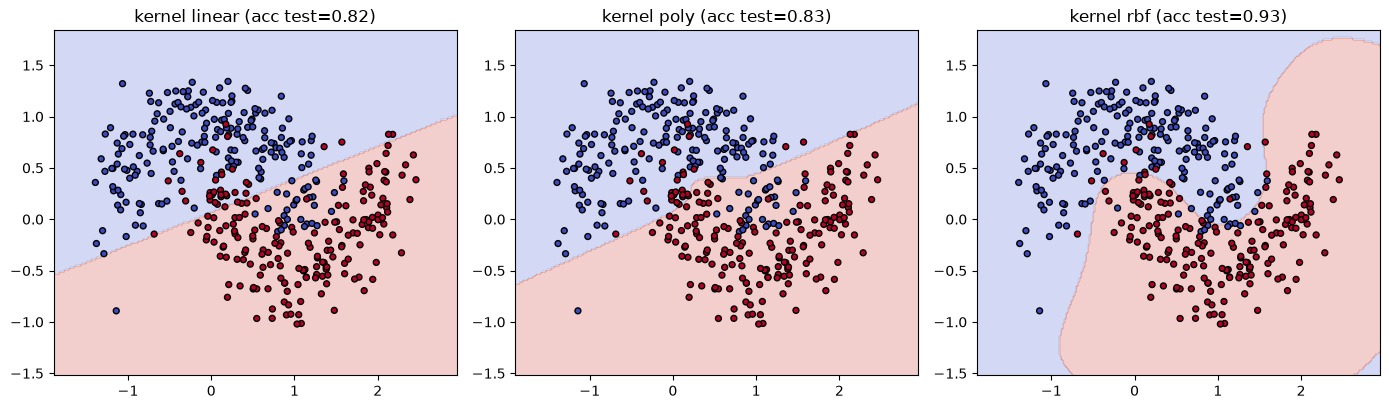

In [9]:

# Comparamos kernels sobre make_moons
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
for ax, (kernel, kw) in zip(axes, [
        ("linear", {}), ("poly", {"degree": 3}), ("rbf", {"gamma": 1.0})]):
    clf = make_pipeline(StandardScaler(), SVC(kernel=kernel, C=1.0, **kw)).fit(X_train, y_train)
    acc = clf.score(X_test, y_test)
    plot_boundary(clf, X, y, ax, f"kernel {kernel} (acc test={acc:.2f})")
plt.tight_layout(); plt.show()


## 4. Efecto de $C$ y $\gamma$ (RBF)

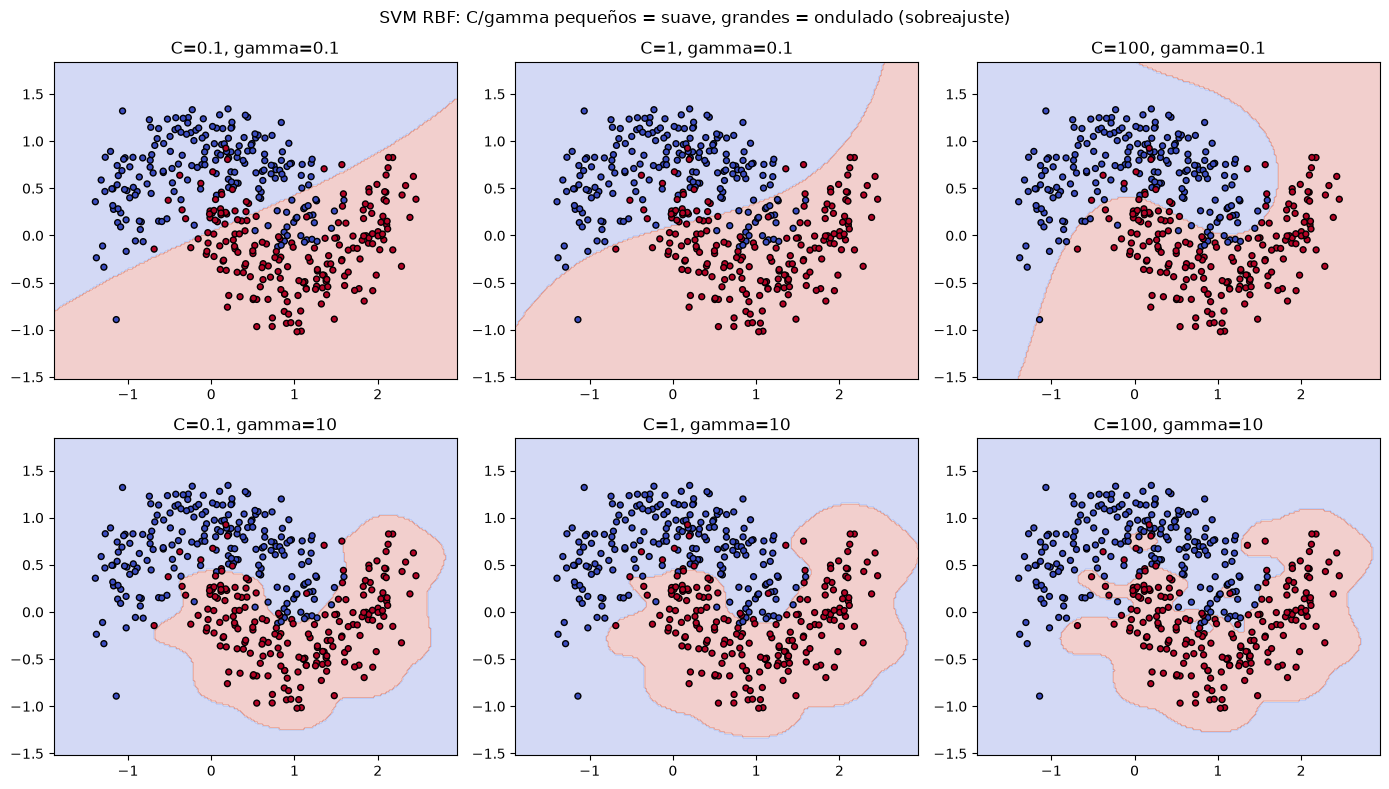

In [10]:

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for i, C in enumerate([0.1, 1, 100]):
    for j, gamma in enumerate([0.1, 10]):
        ax = axes[j, i]
        clf = make_pipeline(StandardScaler(),
                            SVC(kernel="rbf", C=C, gamma=gamma)).fit(X_train, y_train)
        plot_boundary(clf, X, y, ax, f"C={C}, gamma={gamma}")
plt.suptitle("SVM RBF: C/gamma pequeños = suave, grandes = ondulado (sobreajuste)")
plt.tight_layout(); plt.show()


## 5. Ajustar $C$ y $\gamma$ con GridSearch + registrar en MLflow

In [ ]:

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score

pipe = make_pipeline(StandardScaler(), SVC(kernel="rbf", probability=True))
grid = {"svc__C": [0.1, 1, 10, 100], "svc__gamma": [0.01, 0.1, 1, 10]}
gs = GridSearchCV(pipe, grid, cv=5, scoring="accuracy", n_jobs=-1).fit(X_train, y_train)

best = gs.best_estimator_
pred = best.predict(X_test)
metrics = {"cv_best_acc": gs.best_score_,
           "test_acc": accuracy_score(y_test, pred),
           "test_f1": f1_score(y_test, pred)}
params = {"C": gs.best_params_["svc__C"], "gamma": gs.best_params_["svc__gamma"], "kernel": "rbf"}
log_and_register(run_name="SVC-rbf-tuned", params=params, metrics=metrics,
                 model=best, flavor="sklearn",
                 registered_model_name="moons-svm",
                 tags={"algo": "SVC"})
print("Mejores params:", gs.best_params_, "| métricas:", metrics)


## 6. SVR — Regresión por vectores de soporte (bonus)

**Intuición:** la SVR ignora los errores pequeños. Usa un **tubo
$\epsilon$-insensible**: los errores menores que $\epsilon$ no penalizan, y aplica
la misma maquinaria de kernels. Objetivo:

$$
\min \tfrac12\|w\|^2 + C\sum_i (\xi_i + \xi_i^*)\quad
\text{s.a. } |y_i - (w^\top\phi(x_i)+b)| \le \epsilon + \xi.
$$


In [ ]:

from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error
rng = np.random.RandomState(0)
Xr = np.sort(5 * rng.rand(120, 1), axis=0)
yr = np.sin(Xr).ravel() + 0.1 * rng.randn(120)
svr = make_pipeline(StandardScaler(), SVR(kernel="rbf", C=10, gamma=0.5, epsilon=0.1)).fit(Xr, yr)
xx = np.linspace(0, 5, 300).reshape(-1, 1)
plt.figure(figsize=(7,4))
plt.scatter(Xr, yr, s=12, label="datos")
plt.plot(xx, svr.predict(xx), "r", label="SVR (RBF)")
plt.legend(); plt.title(f"Ajuste SVR (RMSE train={np.sqrt(mean_squared_error(yr, svr.predict(Xr))):.3f})")
plt.tight_layout(); plt.show()


## 7. Resumen

- Las SVM maximizan el **margen**; el margen blando equilibra ancho de margen vs
  violaciones mediante $C$.
- El **dual** depende sólo de productos internos → el **truco del kernel** da
  fronteras no lineales de forma barata.
- **RBF** es un default fuerte; ajusta $C$ (regularización) y $\gamma$ (ancho del
  kernel) juntos. Escala siempre las variables primero.
